In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))


# ESS 배터리 수명 예측 · Modeling

Batch 1 학습·내부 검증, Batch 2 최종 평가, Batch 3 추가 평가. 점수는 실제 예측값으로 계산한다.

In [2]:
from src.train import main
OUT=ROOT/'results/experiment'
if not (OUT/'verification.json').exists():
    main(ROOT,OUT,ROOT/'config/experiment.json',ROOT/'config/split_manifest.json')
from src.verify_results import verify_pipeline
display(verify_pipeline(OUT))
chosen=json.loads((OUT/'selected_model.json').read_text())
display(chosen)

{'passed': True,
 'checks': ['config/split hashes',
  'candidate selection independently reproduced',
  'CV fold mean independently recomputed',
  'holdout model reload',
  'reporting gaps independently recomputed',
  'unique IDs',
  'aligned X/y',
  'batch counts',
  '36/10 disjoint split',
  'cycle <=100',
  'input allowlist',
  'protocol group isolation',
  'finite predictions',
  'MAPE independently recomputed',
  'log10 inverse roundtrip',
  'saved model reload predictions',
  'selection/model frozen before external evaluation'],
 'selection_sha256': '2ba96710d0911fe887c2d9e72021d1f3acce0b701462d8eba37c00db47ea71e4',
 'model_sha256': '642ca45cf6a8f123322a17eda0106e0cdf397be9fbf94dab977093ddf43dee85'}

{'candidate_id': 'M3_raw_Ridge',
 'feature_set': 'M3',
 'features': ['log10_dq_var',
  'peak_c_rate',
  'switch_soc',
  'qd_initial_median',
  'qd_slope_10_100'],
 'feature_count': 5,
 'model': 'Ridge',
 'target': 'raw',
 'params': '{"alpha": 1.0}',
 'cv_mape_mean': 8.134262832208663,
 'cv_mape_std': 1.4726044767473419,
 'cv_mae_mean': 72.28067191909432,
 'cv_oof_mape': 8.09306772736515,
 'cell_cv_mape_mean': 8.107190871125404,
 'cell_cv_mape_std': 2.0135168254009486}

## 모델 선택 및 근거

최종 후보는 외삽 가능한 Linear·Ridge·ElasticNet이다. 얕은 Random Forest·제한된 XGBoost·LightGBM은 비교군이다. 후보별 원 수명·로그 수명, M0–M4 및 clean 대안을 공통 충전 정책 Group CV로 비교한다. 최저 MAPE+0.5%p 안에서 피처 수·fold 편차·복잡도 순으로 선택한다. Valid는 한 번 확인하고 최종적으로 Batch 1 전체를 재학습한다.

In [3]:
comparison=pd.read_csv(OUT/'candidate_comparison.csv')
display(comparison.sort_values('cv_mape_mean').drop(columns=['features']).round(4))
display(pd.read_csv(OUT/'feature_addition_effects.csv').round(3))
display(pd.read_csv(OUT/'nested_cv_results.csv').round(3))

,candidate_id,feature_set,feature_count,model,target,params,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_oof_mape,cell_cv_mape_mean,cell_cv_mape_std
10,M1_log10_RandomForest,M1,1,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",8.1001,3.2147,68.1168,8.1720,8.4834,3.2024
26,M3_raw_Ridge,M3,5,Ridge,raw,"{""alpha"": 1.0}",8.1343,1.4726,72.2807,8.0931,8.1072,2.0135
50,M3_clean_raw_Ridge,M3_clean,5,Ridge,raw,"{""alpha"": 1.0}",8.1360,1.4768,72.2882,8.0948,8.1096,2.0128
4,M1_raw_RandomForest,M1,1,RandomForest,raw,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",8.2555,3.5121,69.0580,8.3403,8.7499,3.4932
27,M3_raw_ElasticNet,M3,5,ElasticNet,raw,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.2804,1.6155,74.1556,8.2306,8.1063,1.6637
...,...,...,...,...,...,...,...,...,...,...,...,...
54,M3_clean_raw_LightGBM,M3_clean,5,LightGBM,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.2757,4.4887,93.8400,11.2544,10.8253,4.1106
30,M3_raw_LightGBM,M3,5,LightGBM,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.2757,4.4887,93.8400,11.2544,10.8253,4.1106
66,M4_clean_raw_LightGBM,M4_clean,7,LightGBM,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.6128,3.9361,95.8445,11.5565,10.9425,3.5989
42,M4_raw_LightGBM,M4,7,LightGBM,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.6128,3.9361,95.8445,11.5565,10.9425,3.5989


,candidate_id,feature_set,features,feature_count,model,target,params,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_oof_mape,cell_cv_mape_mean,cell_cv_mape_std,previous_set,previous_cv_mape,improvement_pp
0,M1_raw_Linear,M1,['log10_dq_var'],1,Linear,raw,{},9.288,1.763,82.835,9.308,9.301,1.461,NaN,NaN,NaN
1,M1_raw_Ridge,M1,['log10_dq_var'],1,Ridge,raw,"{""alpha"": 0.01}",9.289,1.759,82.835,9.309,9.303,1.462,NaN,NaN,NaN
2,M1_raw_ElasticNet,M1,['log10_dq_var'],1,ElasticNet,raw,"{""alpha"": 0.0001, ""l1_ratio"": 0.8}",9.289,1.762,82.835,9.308,9.301,1.461,NaN,NaN,NaN
3,M1_raw_RandomForest,M1,['log10_dq_var'],1,RandomForest,raw,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",8.256,3.512,69.058,8.340,8.750,3.493,NaN,NaN,NaN
4,M1_raw_XGBoost,M1,['log10_dq_var'],1,XGBoost,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",10.481,4.492,86.113,10.441,11.378,6.312,NaN,NaN,NaN
5,M1_raw_LightGBM,M1,['log10_dq_var'],1,LightGBM,raw,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.065,3.853,90.664,11.060,10.619,3.512,NaN,NaN,NaN
6,M1_log10_Linear,M1,['log10_dq_var'],1,Linear,log10,{},10.956,4.212,100.842,10.913,10.382,2.429,NaN,NaN,NaN
7,M1_log10_Ridge,M1,['log10_dq_var'],1,Ridge,log10,"{""alpha"": 0.01}",10.956,4.208,100.835,10.914,10.383,2.428,NaN,NaN,NaN
8,M1_log10_ElasticNet,M1,['log10_dq_var'],1,ElasticNet,log10,"{""alpha"": 0.0001, ""l1_ratio"": 0.2}",10.956,4.208,100.833,10.914,10.383,2.428,NaN,NaN,NaN
9,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",8.100,3.215,68.117,8.172,8.483,3.202,NaN,NaN,NaN


,fold,candidate_id,params,mape_pct,mae,mean_signed_error,overprediction_rate_pct
0,0,M2_raw_ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.988,74.244,5.445,62.500
1,1,M3_clean_raw_Ridge,"{""alpha"": 0.01}",8.801,83.772,-12.226,71.429
2,2,M3_log10_Ridge,"{""alpha"": 1.0}",7.107,50.561,25.516,71.429
3,3,M2_log10_Linear,{},15.096,155.546,155.546,100.000
4,4,M2_raw_Ridge,"{""alpha"": 1.0}",9.748,85.299,-71.942,28.571


## 성능 결과 · 과제 Format

Train은 Group CV fold 평균, Valid는 Hold-out 10셀, Test는 Batch 2 39셀이다. Gap은 뒤 단계 오차−앞 단계 오차이며 원논문 기준은 과제 자료의 9.1%다. MAPE는 %, Gap은 %p로 표시한다.

,index,value,unit,note
0,Train (Batch 1 CV),8.134,%,Group CV fold mean; Train36
1,Valid (Batch 1 Hold-out),6.271,%,Hold-out10; one evaluation
2,Test (Batch 2),59.537,%,Final refit on Batch1 46; Test39
3,Gap (Train-Valid),-1.864,%p,Valid - Train; positive: possible overfitting
4,Gap (Valid-Test),53.267,%p,Batch2 - Valid; positive: generalization degra...
5,"Gap (Target-Test), Batch2",50.437,%p,Batch2 - 9.1%; paper reference
6,Test (Batch 3),14.941,%,Same final model; additional Test44
7,Gap (Batch2-Batch3),-44.596,%p,Batch3 - Batch2; positive: Batch3 has higher e...
8,"Gap (Target-Test), Batch3",5.841,%p,Batch3 - 9.1%; paper reference


,partition,n,mape_pct,mae,mean_signed_error,overprediction_rate_pct,baseline_mape_pct
0,Train,36,8.093,71.884,6.143,55.556,19.630
1,Valid,10,6.271,57.735,15.493,70.000,13.683
2,Batch2,39,59.537,288.917,270.869,94.872,72.656
3,Batch3,44,14.941,192.855,-169.009,25.000,20.201


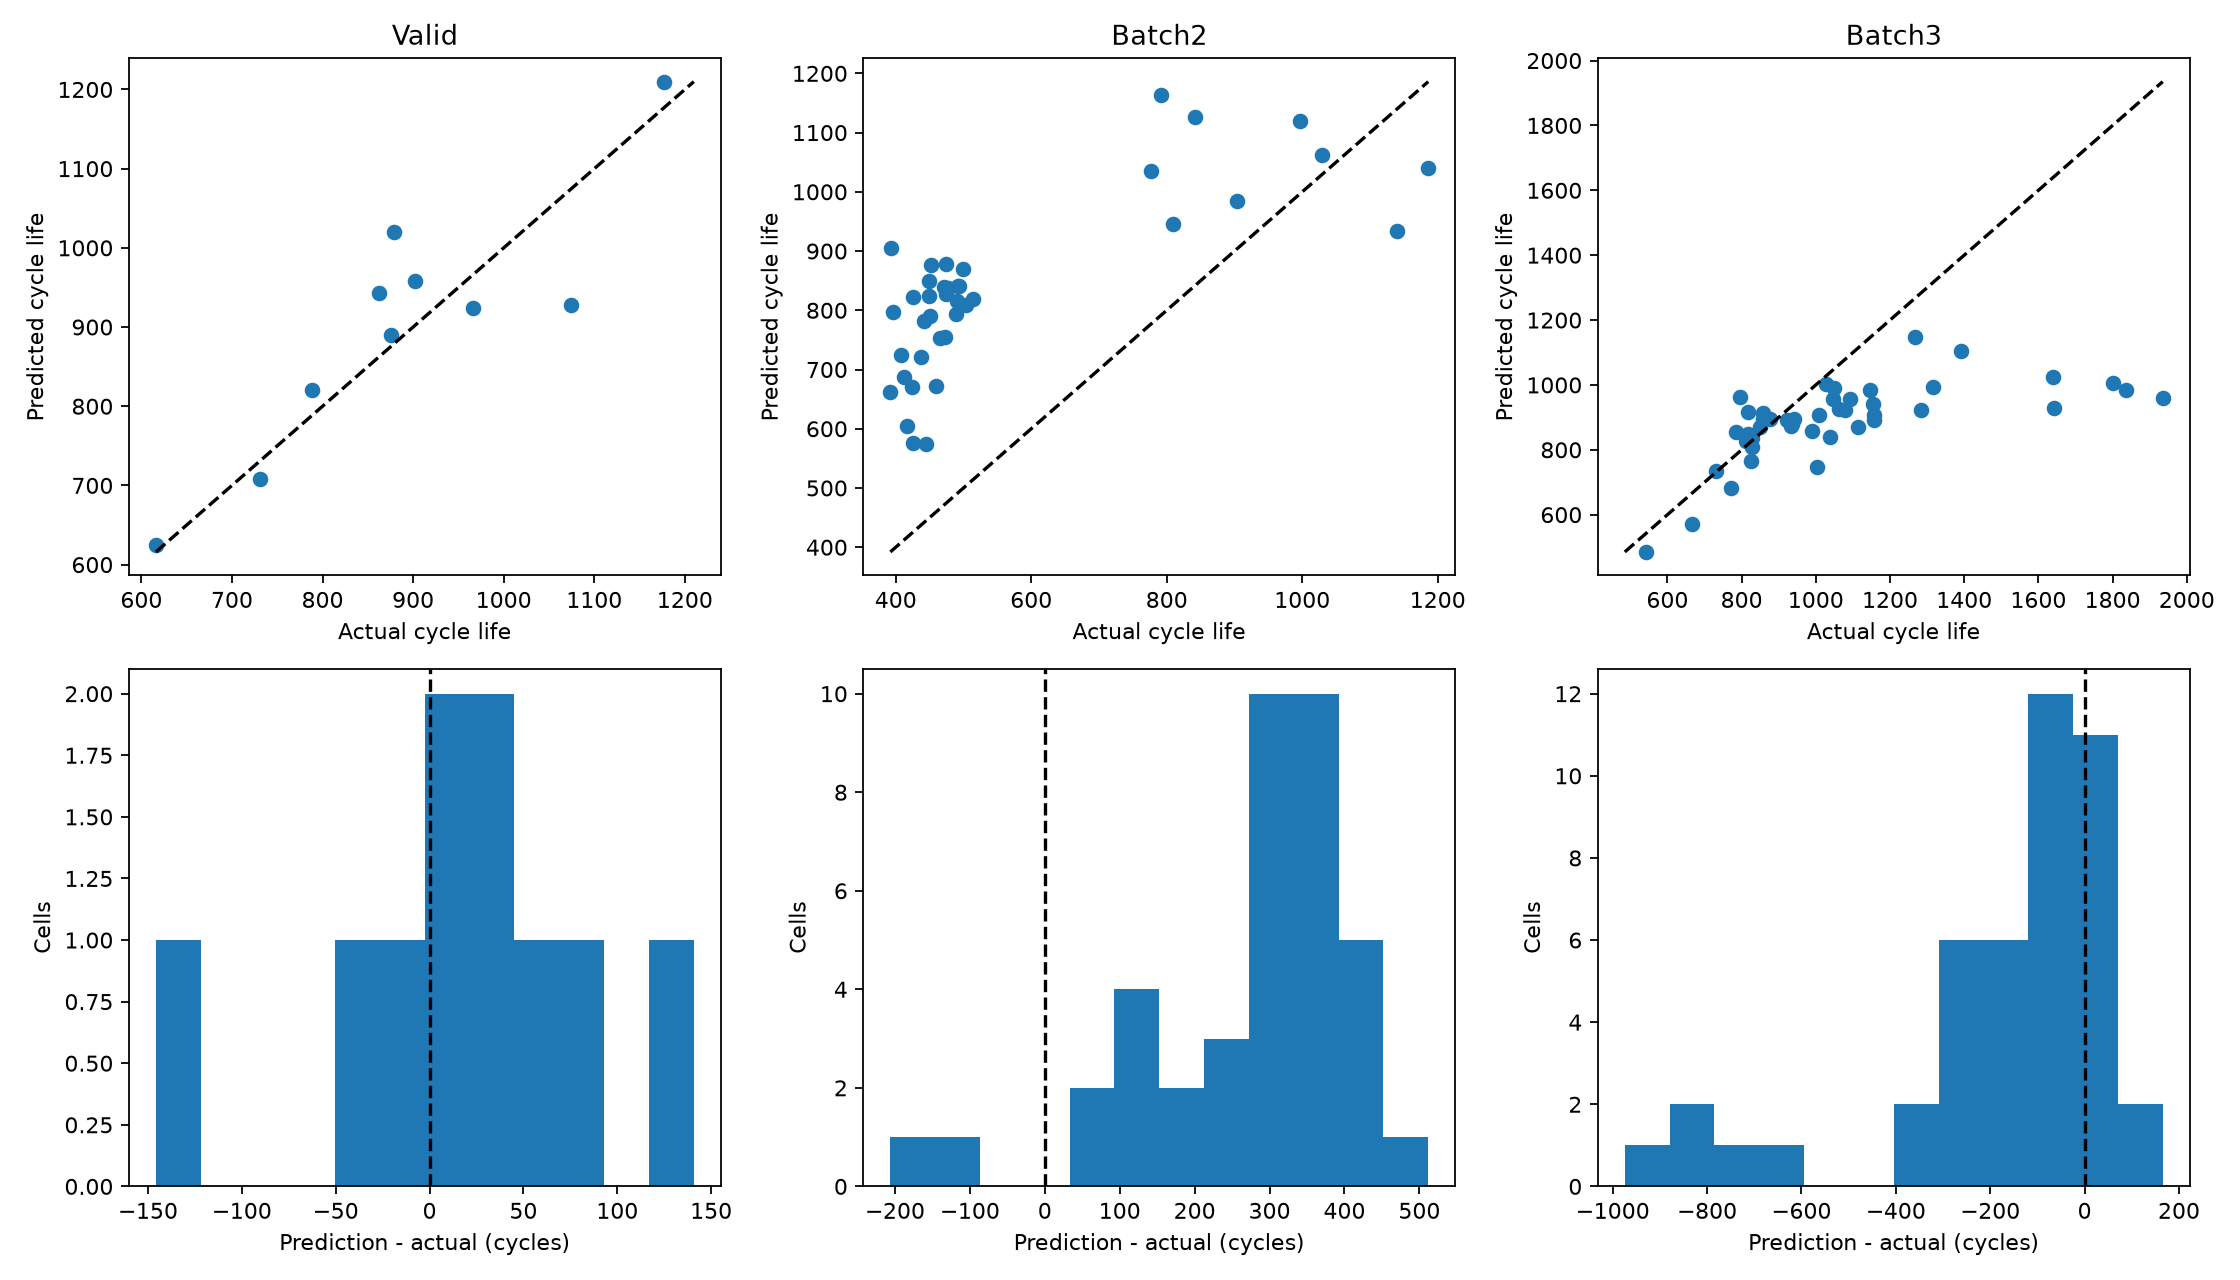

In [4]:
display(pd.read_csv(OUT/'performance_reporting.csv').round(3))
display(pd.read_csv(OUT/'performance.csv').round(3))
display(Image(filename=str(OUT/'prediction_diagnostics.png')))

## 오류 분석

과대 예측과 입력 범위 이탈을 셀별로 확인한다. MAPE가 큰 셀도 평가에서 제외하지 않는다.

In [5]:
errors=pd.read_csv(OUT/'error_analysis_top_cells.csv')
display(errors[['cell_id','policy','actual','predicted','ape_pct','outside_features']].round(3))
display(pd.read_csv(OUT/'error_by_input_range.csv').round(3))
display(pd.read_csv(OUT/'feature_distribution.csv').query('selected == True').round(3))
if (OUT/'linear_coefficients.csv').exists():
    display(pd.read_csv(OUT/'linear_coefficients.csv').round(6))

,cell_id,policy,actual,predicted,ape_pct,outside_features
0,b2c6,3.6C(9%)-5C,393.0,904.800,130.229,switch_soc;qd_slope_10_100
1,b2c15,3.6C(9%)-5C,396.0,797.912,101.493,switch_soc;qd_slope_10_100
2,b2c29,5.2C(58%)-4C,452.0,877.043,94.036,qd_initial_median;qd_slope_10_100
3,b2c31,5.6C(26%)-4.5C,425.0,821.916,93.392,qd_initial_median;qd_slope_10_100
4,b2c11,5.2C(50%)-4.25C,449.0,850.145,89.342,qd_initial_median;qd_slope_10_100
5,b2c42,5.2C(50%)-4.25C,474.0,878.446,85.326,qd_initial_median;qd_slope_10_100
6,b2c18,5.2C(50%)-4.25C,449.0,823.836,83.482,qd_slope_10_100
7,b2c17,5.6C(26%)-4.5C,471.0,838.748,78.078,qd_slope_10_100
8,b2c21,6C(60%)-3C,408.0,723.818,77.406,log10_dq_var;qd_initial_median;qd_slope_10_100
9,b2c41,5.6C(26%)-4.5C,442.0,781.614,76.836,log10_dq_var;qd_initial_median;qd_slope_10_100


,partition,outside_input_range,n,mape_pct,mean_signed_error
0,Batch2,False,6,29.037,65.668
1,Batch2,True,33,65.083,308.178
2,Batch3,False,36,15.551,-184.422
3,Batch3,True,8,12.199,-99.651
4,Train,False,36,8.093,6.143
5,Valid,False,10,6.271,15.493


,batch,feature,selected,n,valid_n,missing_rate_pct,minimum,maximum,median,q25,q75,batch1_min,batch1_max,below_batch1_pct,above_batch1_pct,outside_batch1_pct,wasserstein_distance
0,1,log10_dq_var,True,46,46,0.0,-5.014,-3.349,-3.849,-4.053,-3.666,-5.014,-3.349,0.000,0.000,0.000,0.000
1,2,log10_dq_var,True,39,39,0.0,-4.447,-3.084,-3.486,-3.672,-3.334,-5.014,-3.349,0.000,28.205,28.205,0.340
2,3,log10_dq_var,True,44,44,0.0,-5.112,-3.450,-4.174,-4.322,-4.064,-5.014,-3.349,2.273,0.000,2.273,0.287
3,1,peak_c_rate,True,46,46,0.0,3.600,8.000,6.000,5.400,6.750,3.600,8.000,0.000,0.000,0.000,0.000
4,2,peak_c_rate,True,39,39,0.0,4.800,6.000,5.200,5.000,5.600,3.600,8.000,0.000,0.000,0.000,0.809
5,3,peak_c_rate,True,44,44,0.0,4.800,5.900,5.600,5.000,5.600,3.600,8.000,0.000,0.000,0.000,0.749
6,1,switch_soc,True,46,46,0.0,15.000,80.000,50.000,40.000,67.500,15.000,80.000,0.000,0.000,0.000,0.000
7,2,switch_soc,True,39,39,0.0,9.000,80.000,50.000,26.000,64.500,15.000,80.000,5.128,0.000,5.128,4.438
8,3,switch_soc,True,44,44,0.0,15.000,80.000,54.000,31.000,67.000,15.000,80.000,0.000,0.000,0.000,6.148
9,1,qd_initial_median,True,46,46,0.0,1.056,1.097,1.080,1.077,1.084,1.056,1.097,0.000,0.000,0.000,0.000


,feature,standardized_coefficient,input_unit_coefficient,direction
0,log10_dq_var,-143.290501,-382.908872,decreasing
1,peak_c_rate,-47.470318,-39.910125,decreasing
2,switch_soc,-41.361484,-2.148800,decreasing
3,qd_initial_median,42.118594,5526.035224,increasing
4,qd_slope_10_100,10.580051,380634.518509,increasing


내부 CV의 좋은 성능이 Batch 2로 이어지지 않는다. 초기 용량·기울기의 배치별 관계 변화와 입력 범위 이탈은 오차 원인 가설이다. 높은 ΔQ 상관만으로 15–20% MAPE를 보장할 수 없다. 이 배치들은 설계 EDA와 분석에 이미 사용되었으므로 새로운 미사용 배치의 검증이 필요하다.

## ESS 도메인 해석

초기 100사이클 관측으로 검사·교체 후보를 우선순위화하는 보조 도구로 사용할 수 있다. 수명을 과대 예측하면 교체가 지연될 수 있으므로 실제 운영에는 온도·SOC·부하·휴지시간·화학계 차이, 측정 교정, 불확실성 및 팩 단위 검증이 필요하다.

참고문헌: Severson et al. (2019), Nature Energy 4, 383–391.

팀: 울산캠퍼스 4반 정예지.